# Random Forest

> Objetivo: treinar uma Random Forest, avaliar o desempenho no teste e afiná-la, testando também o efeito do SMOTE.

> O pré-processamento (imputação + one-hot encoding) é partilhado através de `preprocessing.py`, ajustado apenas com o treino dentro de uma pipeline (feedback #1, #5, #6).

## 1) Importação e leitura dos dados

In [8]:
# importações de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import preprocessing as prep

# Carregamento com as transformações determinísticas; imputação/encoding ficam
# na pipeline (feedback #1, #5). Não se usa o ortho_eda_clean.csv (já imputado).
X, y = prep.carregar_dados()

## 2) Preparação dos dados

In [9]:
# Split estratificado único (feedback #1). O teste é usado uma só vez, no fim.
X_train, X_test, y_train, y_test = prep.dividir_treino_teste(X, y)
print("treino:", X_train.shape, "| teste:", X_test.shape)

treino: (183, 13) | teste: (79, 13)


## 3) Treino do modelo (Random Forest)

In [10]:
# Baseline: Random Forest dentro da pipeline (imputação + OHE ajustados só no treino)
pipe_rf_base = prep.construir_pipeline(
    RandomForestClassifier(random_state=42), X
)
pipe_rf_base.fit(X_train, y_train)

,steps,"[('prep', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 4) Avaliação do modelo

              precision    recall  f1-score   support

           0     0.9103    1.0000    0.9530        71
           1     1.0000    0.1250    0.2222         8

    accuracy                         0.9114        79
   macro avg     0.9551    0.5625    0.5876        79
weighted avg     0.9193    0.9114    0.8790        79

AUC (probabilidades): 0.7368


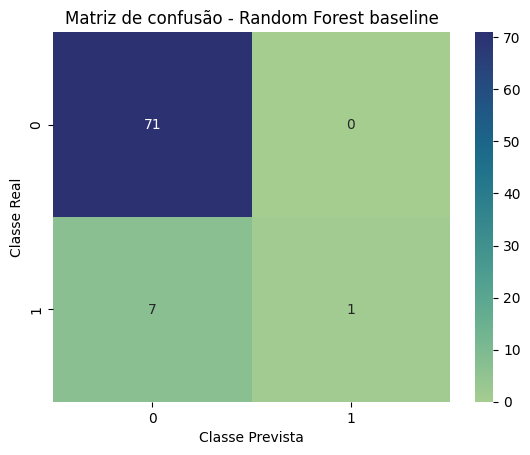

In [11]:
# Avaliação do baseline no teste: matriz de confusão + relatório + AUC (probabilidades)
res_rf_base = prep.avaliar_teste(pipe_rf_base, X_test, y_test, titulo="Random Forest baseline")

In [12]:
# Validação cruzada estratificada APENAS no treino (feedback #1), AUC de probabilidades
print("=== Validação cruzada (treino) — Random Forest baseline ===")
_ = prep.validacao_cruzada_treino(pipe_rf_base, X_train, y_train)

=== Validação cruzada (treino) — Random Forest baseline ===
              precision    recall  f1-score   support

           0     0.9116    1.0000    0.9538       165
           1     1.0000    0.1111    0.2000        18

    accuracy                         0.9126       183
   macro avg     0.9558    0.5556    0.5769       183
weighted avg     0.9203    0.9126    0.8796       183

AUC CV (probabilidades): 0.7813


## 5) Melhoria prática da Random Forest

Com base na análise de redundância (EDA / `AD_final`), removemos variáveis compostas/derivadas e afinamos a RF:
1. remover `IMC`, `Peso`, `Altura_cm`;
2. remover `WT_0` e componentes (`WD_0`, `WR_0`, `WAtotal_0`);
3. afinar por `GridSearchCV` com validação cruzada **só no treino**, otimizando a **AUC**.

Variáveis removidas: ['IMC', 'Peso', 'Altura_cm', 'WT_0', 'WD_0', 'WR_0', 'WAtotal_0']
Melhores parâmetros RF: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 3, 'modelo__n_estimators': 200}
Melhor AUC média (CV, treino): 0.8136

=== Avaliação no TESTE — RF melhorada ===
              precision    recall  f1-score   support

           0     0.9211    0.9859    0.9524        71
           1     0.6667    0.2500    0.3636         8

    accuracy                         0.9114        79
   macro avg     0.7939    0.6180    0.6580        79
weighted avg     0.8953    0.9114    0.8928        79

AUC (probabilidades): 0.6813


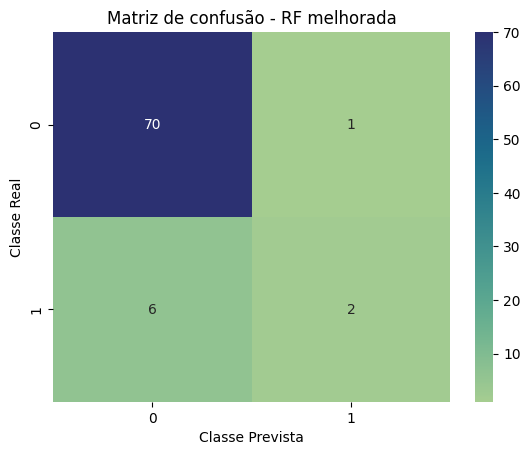


=== Validação cruzada (treino) — RF melhorada ===
              precision    recall  f1-score   support

           0     0.9390    0.9333    0.9362       165
           1     0.4211    0.4444    0.4324        18

    accuracy                         0.8852       183
   macro avg     0.6800    0.6889    0.6843       183
weighted avg     0.8881    0.8852    0.8866       183

AUC CV (probabilidades): 0.8067


In [13]:
# Cenário de features reduzido + afinamento da RF (tudo com pipeline, CV só no treino).
remover_rf = ["IMC", "Peso", "Altura_cm", "WT_0", "WD_0", "WR_0", "WAtotal_0"]
X_rf = X.drop(columns=remover_rf)
X_train_rf = X_train.drop(columns=remover_rf)
X_test_rf = X_test.drop(columns=remover_rf)

pipe_rf = prep.construir_pipeline(
    RandomForestClassifier(random_state=42, class_weight="balanced_subsample"), X_rf
)
param_rf = {
    "modelo__n_estimators": [200, 400],
    "modelo__max_depth": [None, 8, 14],
    "modelo__min_samples_leaf": [1, 3],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(pipe_rf, param_rf, scoring="roc_auc", cv=cv, n_jobs=-1)
grid_rf.fit(X_train_rf, y_train)

print("Variáveis removidas:", remover_rf)
print("Melhores parâmetros RF:", grid_rf.best_params_)
print("Melhor AUC média (CV, treino):", round(grid_rf.best_score_, 4))

print("\n=== Avaliação no TESTE — RF melhorada ===")
prep.avaliar_teste(grid_rf.best_estimator_, X_test_rf, y_test, titulo="RF melhorada")

print("\n=== Validação cruzada (treino) — RF melhorada ===")
_ = prep.validacao_cruzada_treino(grid_rf.best_estimator_, X_train_rf, y_train)

## 6) SMOTE — exemplos sintéticos da classe minoritária (feedback #4)

Testamos o **SMOTE** na Random Forest. Usa-se a `Pipeline` do **imbalanced-learn**, para o SMOTE ser aplicado **apenas no `fit`** (folds de treino) e nunca à validação/teste. Comparam-se as métricas **com** e **sem** SMOTE.

> Nota: o dataset é pequeno e a minoria tem poucos casos — os ganhos do SMOTE podem ser instáveis.

In [14]:
# Compara a Random Forest COM e SEM SMOTE, por CV no treino e no teste.
for etiqueta, usar_smote in [("SEM SMOTE", False), ("COM SMOTE", True)]:
    print("\n" + "=" * 55)
    print(f"Random Forest — {etiqueta}")
    print("=" * 55)
    pipe = prep.construir_pipeline(
        RandomForestClassifier(random_state=42), X, usar_smote=usar_smote
    )
    pipe.fit(X_train, y_train)
    print("--- Teste ---")
    prep.avaliar_teste(pipe, X_test, y_test, titulo=f"RF {etiqueta}", plot=False)
    print("--- Validação cruzada (treino) ---")
    prep.validacao_cruzada_treino(pipe, X_train, y_train)


Random Forest — SEM SMOTE
--- Teste ---
              precision    recall  f1-score   support

           0     0.9103    1.0000    0.9530        71
           1     1.0000    0.1250    0.2222         8

    accuracy                         0.9114        79
   macro avg     0.9551    0.5625    0.5876        79
weighted avg     0.9193    0.9114    0.8790        79

AUC (probabilidades): 0.7368
--- Validação cruzada (treino) ---
              precision    recall  f1-score   support

           0     0.9116    1.0000    0.9538       165
           1     1.0000    0.1111    0.2000        18

    accuracy                         0.9126       183
   macro avg     0.9558    0.5556    0.5769       183
weighted avg     0.9203    0.9126    0.8796       183

AUC CV (probabilidades): 0.7813

Random Forest — COM SMOTE
--- Teste ---
              precision    recall  f1-score   support

           0     0.9067    0.9577    0.9315        71
           1     0.2500    0.1250    0.1667         8

    